# Lane predictions

Implementing common computer vision techniques to find the lane lines from a dash camera.

In [1]:
import os, urllib.request

if not os.path.exists('data/test_images'):
    os.makedirs('data/test_images', exist_ok=True)
    os.makedirs('data/test_videos', exist_ok=True)
    os.makedirs('data/test_videos_output', exist_ok=True)

    base = "https://raw.githubusercontent.com/udacity/CarND-LaneLines-P1/master/"
    files = [
        "test_images/solidWhiteRight.jpg",
        "test_images/solidYellowCurve.jpg",
        "test_images/solidYellowCurve2.jpg",
        "test_images/solidYellowLeft.jpg",
        "test_images/whiteCarLaneSwitch.jpg",
        "test_images/solidWhiteCurve.jpg",
        "test_videos/solidWhiteRight.mp4",
        "test_videos/solidYellowLeft.mp4",
        "test_videos/challenge.mp4",
    ]
    for f in files:
        print(f"Downloading {f}...")
        urllib.request.urlretrieve(base + f, f"data/{f}")
    print("Done.")

## Pipeline overview

The full lane detection pipeline applies these steps in sequence to each frame:

1. **Grayscale** — reduce 3-channel color to 1-channel intensity
2. **Gaussian blur** — smooth noise before edge detection
3. **Canny edge detection** — find sharp intensity gradients
4. **Region of interest** — mask out everything outside the road area
5. **Hough transform** — detect line segments from edge pixels
6. **Overlay** — blend detected lane lines back onto the original frame

In [2]:
import math
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import cv2
%matplotlib inline

In [3]:
CONFIG = {
    'gaussian_kernel': 5,
    'canny_low': 150,
    'canny_high': 250,
    'hough_rho': 1,
    'hough_theta': np.pi / 180,
    'hough_threshold': 40,
    'hough_min_len': 1,
    'hough_max_gap': 10,
    'slope_left_min': -3,
    'slope_left_max': -0.1,
    'slope_right_min': 0.1,
    'slope_right_max': 2,
}
DEFAULT_LEFT_SLOPE,  DEFAULT_LEFT_INTERCEPT  = -1.4, 1250
DEFAULT_RIGHT_SLOPE, DEFAULT_RIGHT_INTERCEPT = 1.7, -50

## Load image

Read a single test image with OpenCV (`cv2.imread` returns BGR) and display it. This image is used throughout the following cells to visualize each processing step in isolation.

This image is of type: <class 'numpy.ndarray'> with dimensions: (540, 960, 3)


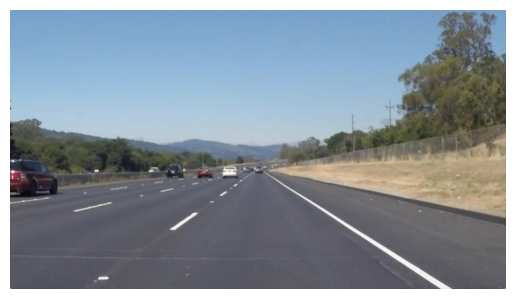

In [4]:
image = mpimg.imread('data/test_images/solidWhiteRight.jpg')
print('This image is of type:', type(image), 'with dimensions:', image.shape)
plt.imshow(image)
plt.axis('off')
plt.show()

### Step 1 — Grayscale conversion

Convert the BGR image to a single-channel grayscale image using `cv2.cvtColor`. Edge detection algorithms operate on intensity gradients, so color information is not needed and reducing to one channel speeds up subsequent processing.

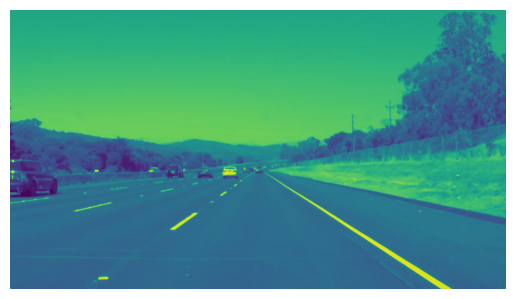

In [5]:
def grayscale(img):
    """Applies the Grayscale transform
    This will return an image with only one color channel
    but NOTE: to see the returned image as grayscale
    (assuming your grayscaled image is called 'gray')
    you should call plt.imshow(gray, cmap='gray')"""
    return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    # Or use BGR2GRAY if you read an image with cv2.imread()
    # return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

gray_img = grayscale(image)
plt.imshow(gray_img)
plt.axis('off')
plt.show()

### Step 2 — Gaussian blur

Apply a Gaussian kernel (size 5×5) to smooth the image before edge detection. This reduces high-frequency noise that would otherwise produce spurious edges. A larger kernel produces more smoothing but risks blurring real edges.

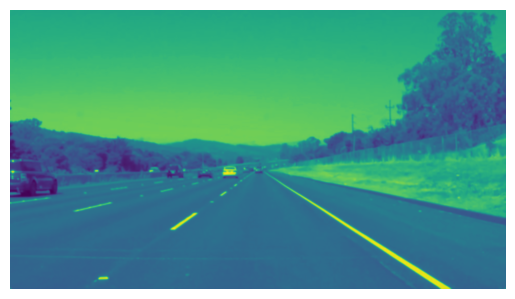

In [6]:
def gaussian_blur(img, kernel_size):
    """Applies a Gaussian Noise kernel"""
    return cv2.GaussianBlur(img, (kernel_size, kernel_size), 0)

gauss_img = gaussian_blur(gray_img, CONFIG['gaussian_kernel'])
plt.imshow(gauss_img)
plt.axis('off')
plt.show()

### Step 3 — Canny edge detection

Run the Canny algorithm (`cv2.Canny`) with a low threshold of 150 and high threshold of 250. Pixels with gradient above 250 are strong edges; those between 150–250 are kept only if connected to a strong edge. Pixels below 150 are discarded. The 1:~1.7 ratio keeps edges tight while suppressing noise.

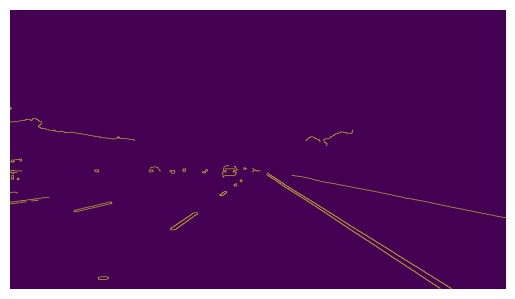

In [7]:
def canny(img, low_threshold, high_threshold):
    """Applies the Canny transform"""
    return cv2.Canny(img, low_threshold, high_threshold)

canny_img = canny(gauss_img, CONFIG['canny_low'], CONFIG['canny_high'])
plt.imshow(canny_img)
plt.axis('off')
plt.show()

### Step 4 — Region of interest masking

Define a polygon that covers only the road area (a trapezoid converging toward the horizon). A filled mask is applied so that edges outside this region — road signs, oncoming cars, sky — are zeroed out. The polygon vertices are chosen relative to the image dimensions to generalize across different image sizes.

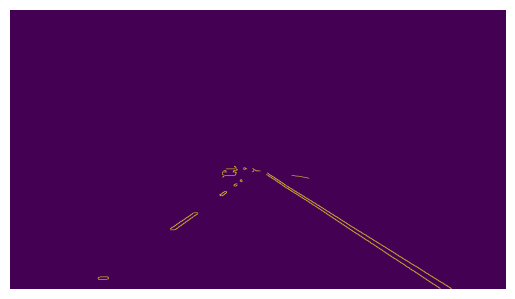

In [8]:
def region_of_interest(img, vertices):
    mask = np.zeros_like(img)
    if len(img.shape) > 2:
        ignore_mask_color = (255,) * img.shape[2]
    else:
        ignore_mask_color = 255
    cv2.fillPoly(mask, vertices, ignore_mask_color)
    return cv2.bitwise_and(img, mask)

h, w = canny_img.shape
roi_vertic = np.array([
    [int(w * 0.1),  h],
    [int(w * 0.45), int(h * 0.55)],
    [int(w * 0.55), int(h * 0.55)],
    [w,             h],
], np.int32)
roi_img = region_of_interest(canny_img, [roi_vertic])
plt.imshow(roi_img)
plt.axis('off')
plt.show()

### Step 5 — Hough transform & lane line drawing

`hough_lines` runs `cv2.HoughLinesP` (probabilistic Hough transform) to detect line segments from the masked edge image, then passes them to `draw_lines`.

`draw_lines` separates segments into left and right lanes by slope sign (negative slope → left lane, positive → right lane), fits a single line through each group using the segment endpoints, and extrapolates it from the bottom of the image to the horizon. This converts the many short Hough segments into two solid, continuous lane lines.

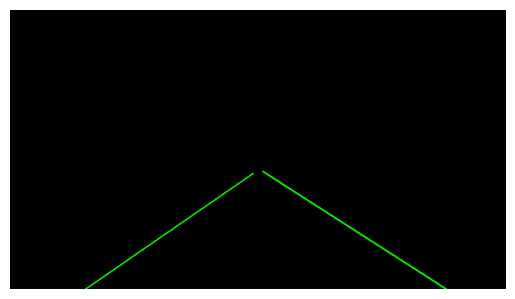

In [9]:
def _compute_lane_params(lines):
    """Return (kl, bl, kr, br) averaged from Hough segments, or None if no lines."""
    if lines is None:
        return None
    k_left, b_left, k_right, b_right = [], [], [], []
    for line in lines:
        x1, y1, x2, y2 = line[0]
        if y2 == y1:
            continue
        k = (x2 - x1) / (y2 - y1)
        b = x1 - k * y1
        if CONFIG['slope_left_min'] < k < CONFIG['slope_left_max']:
            k_left.append(k)
            b_left.append(b)
        elif CONFIG['slope_right_min'] < k < CONFIG['slope_right_max']:
            k_right.append(k)
            b_right.append(b)
    return (
        np.mean(k_left) if k_left else DEFAULT_LEFT_SLOPE,
        np.mean(b_left) if b_left else DEFAULT_LEFT_INTERCEPT,
        np.mean(k_right) if k_right else DEFAULT_RIGHT_SLOPE,
        np.mean(b_right) if b_right else DEFAULT_RIGHT_INTERCEPT,
    )


def _draw_lane(img, kl, bl, kr, br, color=[0, 255, 0], thickness=2):
    """Draw two lane lines onto img using pre-computed slope/intercept."""
    try:
        y_ref = img.shape[1]
        x1_left = int(kl * y_ref + bl)
        x2_left = int(img.shape[1] * 0.49)
        y2_left = int((x2_left - bl) / kl)
        cv2.line(img, (x1_left, y_ref), (x2_left, y2_left), color, thickness)

        x1_right = int(kr * y_ref + br)
        x2_right = int(img.shape[1] * 0.51)
        y2_right = int((x2_right - br) / kr)
        cv2.line(img, (x1_right, y_ref), (x2_right, y2_right), color, thickness)
    except (ValueError, ZeroDivisionError):
        pass


def draw_lines(img, lines, color=[0, 255, 0], thickness=2):
    params = _compute_lane_params(lines)
    if params is None:
        return None
    _draw_lane(img, *params, color=color, thickness=thickness)
    return params


def hough_lines(img, rho, theta, threshold, min_line_len, max_line_gap):
    """`img` should be the output of a Canny transform."""
    lines = cv2.HoughLinesP(img, rho, theta, threshold, np.array([]),
                            minLineLength=min_line_len, maxLineGap=max_line_gap)
    line_img = np.zeros((img.shape[0], img.shape[1], 3), dtype=np.uint8)
    draw_lines(line_img, lines)
    return line_img


detect_line = hough_lines(roi_img, CONFIG['hough_rho'], CONFIG['hough_theta'],
                          CONFIG['hough_threshold'], CONFIG['hough_min_len'], CONFIG['hough_max_gap'])
plt.imshow(detect_line)
plt.axis('off')
plt.show()

### Step 6 — Overlay

Blend the lane line image (drawn on a black canvas) onto the original color image using `cv2.addWeighted`. The weight parameters control opacity — the original image retains most of its brightness while the lane lines are drawn on top at a fixed opacity.

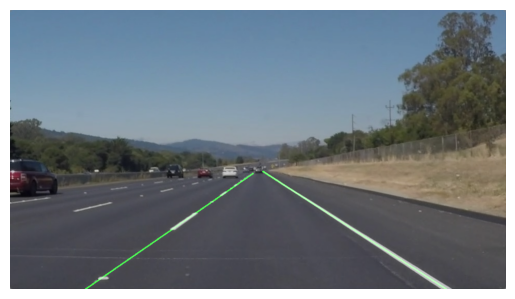

In [10]:
def weighted_img(img, initial_img, α=0.8, β=1., γ=0.):
    """
    `img` is the output of the hough_lines(), An image with lines drawn on it.
    Should be a blank image (all black) with lines drawn on it.
    
    `initial_img` should be the image before any processing.
    
    The result image is computed as follows:
    
    initial_img * α + img * β + γ
    NOTE: initial_img and img must be the same shape!
    """
    return cv2.addWeighted(initial_img, α, img, β, γ)
    
wi = weighted_img(detect_line, image)
plt.imshow(wi)
plt.axis('off')
plt.show()

## Full pipeline

`process_image` chains all six steps into a single function. It takes a raw BGR frame and returns the frame with lane lines overlaid. This is the function that will be applied to every frame when processing videos.

In [11]:
def process_image(image):
    gray  = grayscale(image)
    blur  = gaussian_blur(gray, CONFIG['gaussian_kernel'])
    edges = canny(blur, CONFIG['canny_low'], CONFIG['canny_high'])
    h, w  = edges.shape
    roi_v = np.array([
        [int(w * 0.1),  h],
        [int(w * 0.45), int(h * 0.55)],
        [int(w * 0.55), int(h * 0.55)],
        [w,             h],
    ], np.int32)
    roi        = region_of_interest(edges, [roi_v])
    detect_line = hough_lines(roi, CONFIG['hough_rho'], CONFIG['hough_theta'],
                              CONFIG['hough_threshold'], CONFIG['hough_min_len'], CONFIG['hough_max_gap'])
    return weighted_img(detect_line, image)


# Video variant: applies exponential moving average to smooth lane jitter across frames
ALPHA = 0.3
_video_state = {}

def process_image_video(image):
    gray  = grayscale(image)
    blur  = gaussian_blur(gray, CONFIG['gaussian_kernel'])
    edges = canny(blur, CONFIG['canny_low'], CONFIG['canny_high'])
    h, w  = edges.shape
    roi_v = np.array([
        [int(w * 0.1),  h],
        [int(w * 0.45), int(h * 0.55)],
        [int(w * 0.55), int(h * 0.55)],
        [w,             h],
    ], np.int32)
    roi   = region_of_interest(edges, [roi_v])
    lines = cv2.HoughLinesP(roi, CONFIG['hough_rho'], CONFIG['hough_theta'],
                            CONFIG['hough_threshold'], np.array([]),
                            minLineLength=CONFIG['hough_min_len'],
                            maxLineGap=CONFIG['hough_max_gap'])
    params    = _compute_lane_params(lines)
    line_img  = np.zeros((h, w, 3), dtype=np.uint8)
    if params:
        kl, bl, kr, br = params
        if _video_state:
            kl = ALPHA * kl + (1 - ALPHA) * _video_state['kl']
            bl = ALPHA * bl + (1 - ALPHA) * _video_state['bl']
            kr = ALPHA * kr + (1 - ALPHA) * _video_state['kr']
            br = ALPHA * br + (1 - ALPHA) * _video_state['br']
        _video_state.update({'kl': kl, 'bl': bl, 'kr': kr, 'br': br})
        _draw_lane(line_img, kl, bl, kr, br)
    elif _video_state:
        _draw_lane(line_img, _video_state['kl'], _video_state['bl'],
                   _video_state['kr'], _video_state['br'])
    return weighted_img(line_img, image)

## Testing on images

Run `process_image` on all static test images and display the results in a grid. This is a quick visual check that the pipeline works correctly before applying it to video.

In [12]:
import os
test_imgs = os.listdir('data/test_images/')
test_imgs

['solidYellowCurve.jpg',
 'solidYellowLeft.jpg',
 'solidYellowCurve2.jpg',
 'solidWhiteRight.jpg',
 'whiteCarLaneSwitch.jpg',
 'solidWhiteCurve.jpg']

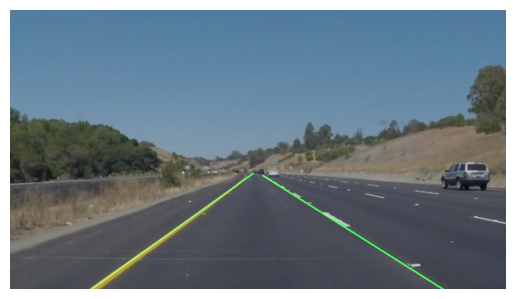

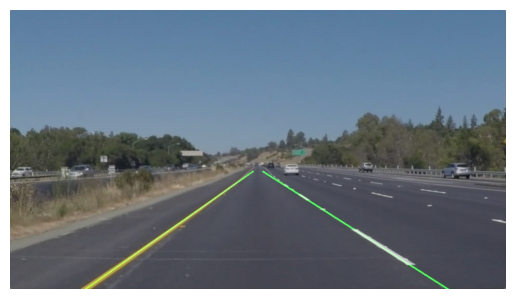

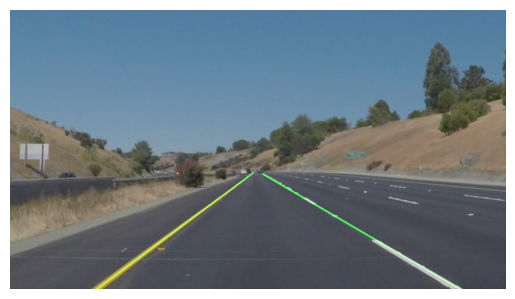

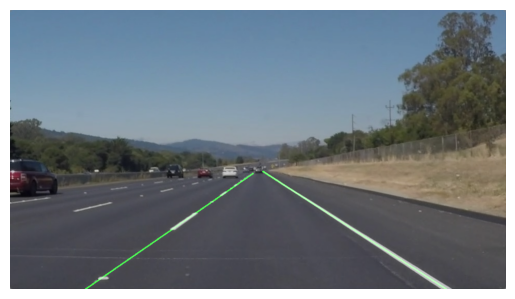

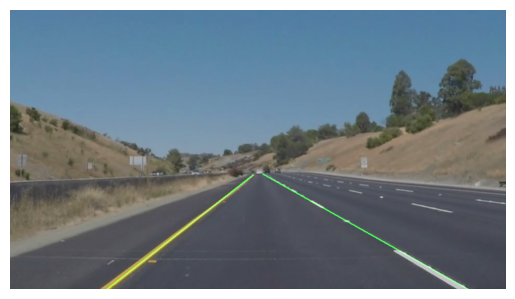

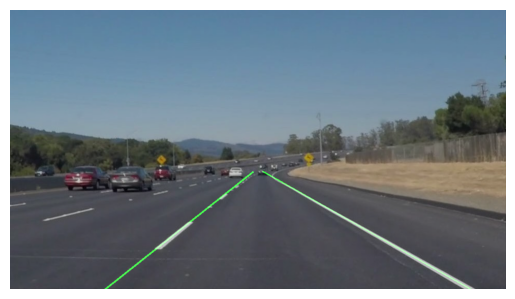

In [13]:
for img_name in test_imgs:
    img = mpimg.imread("data/test_images/" + img_name)
    result = process_image(img)
    plt.imshow(result)
    plt.axis('off')
    plt.show()

In [14]:
from moviepy import VideoFileClip
from IPython.display import Video

## Video processing

Apply `process_image` frame-by-frame to test videos using MoviePy's `fl_image` transform. Each video is read, processed, and written to an output file. The results are then displayed inline for review.

In [15]:
test_videos = os.listdir('data/test_videos/')
test_videos

['solidWhiteRight.mp4', 'challenge.mp4', 'solidYellowLeft.mp4']

In [16]:
for video_name in test_videos:
    _video_state.clear()  # reset smoothing state between clips
    clip = VideoFileClip("data/test_videos/" + video_name)
    edited_clip = clip.transform(lambda get_frame, t: process_image_video(get_frame(t)))
    edited_clip.write_videofile("data/test_videos_output/" + video_name, audio=False, fps=clip.fps)
    Video("data/test_videos_output/" + video_name)

MoviePy - Building video data/test_videos_output/solidWhiteRight.mp4.
MoviePy - Writing video data/test_videos_output/solidWhiteRight.mp4



MoviePy - Done !
MoviePy - video ready data/test_videos_output/solidWhiteRight.mp4
MoviePy - Building video data/test_videos_output/challenge.mp4.
MoviePy - Writing video data/test_videos_output/challenge.mp4



MoviePy - Done !
MoviePy - video ready data/test_videos_output/challenge.mp4
MoviePy - Building video data/test_videos_output/solidYellowLeft.mp4.
MoviePy - Writing video data/test_videos_output/solidYellowLeft.mp4



MoviePy - Done !
MoviePy - video ready data/test_videos_output/solidYellowLeft.mp4


In [17]:
Video("data/test_videos_output/solidWhiteRight.mp4")

In [18]:
Video("data/test_videos_output/solidYellowLeft.mp4")

In [19]:
Video("data/test_videos_output/challenge.mp4")